In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Add, Concatenate
from tensorflow.keras.callbacks import EarlyStopping


In [18]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"


In [19]:
df = pd.read_csv("../data/final/full_cleaned_labelled.csv")

target = "OAB"

drop_features = [
    "KIQ005_BIN",
    "KIQ481_BIN",
    "OAB"
]

X = df.drop(columns=drop_features)
y = df[target]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    #random_state=42
    random_state=SEED
)


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
smote = SMOTE(random_state=SEED)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


In [23]:
def build_deep_mlp(input_dim):

    inputs = Input(shape=(input_dim,))

    x = Dense(128, activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation="relu")(x)
    x = BatchNormalization()(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    return model


In [24]:
def build_residual_nn(input_dim):

    inputs = Input(shape=(input_dim,))

    x = Dense(128, activation="relu")(inputs)
    x = BatchNormalization()(x)

    # Residual Block
    res = Dense(128, activation="relu")(x)
    res = BatchNormalization()(res)

    res = Dense(128, activation="relu")(res)
    res = BatchNormalization()(res)

    x = Add()([x, res])
    x = Dropout(0.3)(x)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    return model


In [25]:
def build_wide_deep(input_dim):

    inputs = Input(shape=(input_dim,))

    # Wide path
    wide = Dense(1, activation="linear")(inputs)

    # Deep path
    deep = Dense(128, activation="relu")(inputs)
    deep = BatchNormalization()(deep)
    deep = Dropout(0.3)(deep)

    deep = Dense(64, activation="relu")(deep)
    deep = BatchNormalization()(deep)

    deep = Dense(32, activation="relu")(deep)

    merged = Concatenate()([wide, deep])

    outputs = Dense(1, activation="sigmoid")(merged)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    return model


In [26]:
def train_and_evaluate(model, name):

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_smote,
        y_train_smote,
        validation_split=0.2,
        epochs=100,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0,
        shuffle=True
    )

    y_prob = model.predict(X_test_scaled).ravel()
    y_pred = (y_prob > 0.6).astype(int)

    print(f"\n{name} RESULTS")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("F1:", f1_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    return model


In [27]:
input_dim = X_train_smote.shape[1]

models = {
    "Deep MLP": build_deep_mlp(input_dim),
    "Residual NN": build_residual_nn(input_dim),
    "Wide & Deep": build_wide_deep(input_dim)
}

trained_models = {}

for name, model in models.items():
    trained_model = train_and_evaluate(model, name)
    trained_models[name] = trained_model



E0000 00:00:1787322596.997319 6088430 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


E0000 00:00:1787322602.199004 6088430 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Deep MLP RESULTS
Accuracy: 0.9304865938430983
ROC AUC: 0.9665749610369864
F1: 0.8942598187311178
Precision: 0.8087431693989071
Recall: 1.0
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


E0000 00:00:1787322615.252726 6088430 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Residual NN RESULTS
Accuracy: 0.9304865938430983
ROC AUC: 0.9615050176759037
F1: 0.8929663608562691
Precision: 0.8156424581005587
Recall: 0.9864864864864865
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Wide & Deep RESULTS
Accuracy: 0.929493545183714
ROC AUC: 0.9661473182042803
F1: 0.8925869894099848
Precision: 0.8082191780821918
Recall: 0.9966216216216216


E0000 00:00:1787322621.112960 6088430 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [28]:
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Store probabilities and predictions
model_outputs = {}

for name, model in trained_models.items():
    y_prob = model.predict(X_test_scaled).ravel()
    y_pred = (y_prob > 0.6).astype(int)  # using your chosen threshold
    
    model_outputs[name] = {
        "prob": y_prob,
        "pred": y_pred
    }

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step


<Figure size 640x480 with 0 Axes>

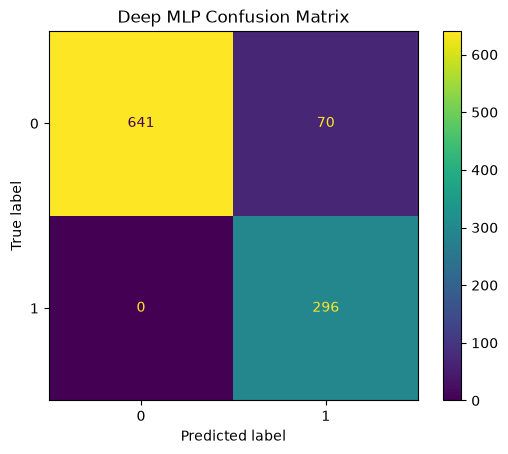

<Figure size 640x480 with 0 Axes>

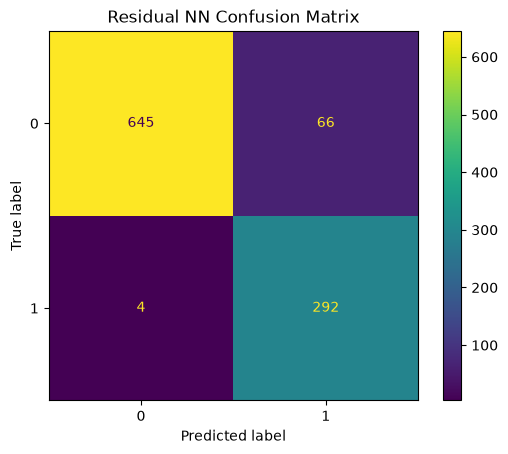

<Figure size 640x480 with 0 Axes>

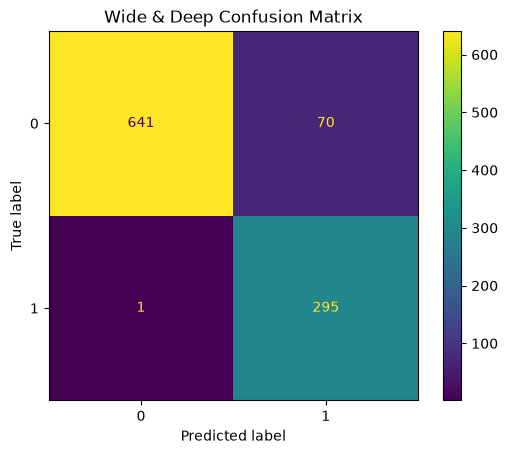

In [29]:
for name in model_outputs:
    y_pred = model_outputs[name]["pred"]

    plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

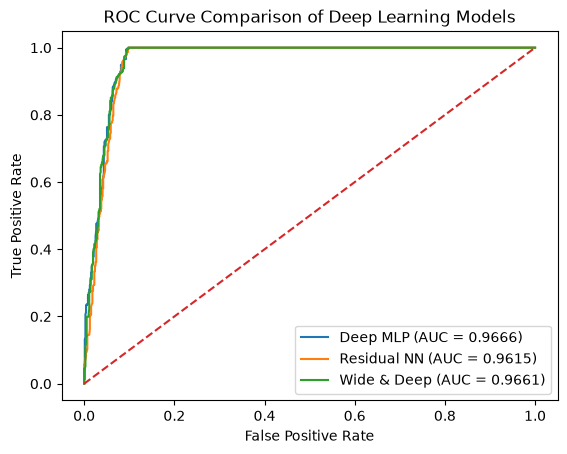

In [30]:
plt.figure()

for name in model_outputs:
    y_prob = model_outputs[name]["prob"]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison of Deep Learning Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

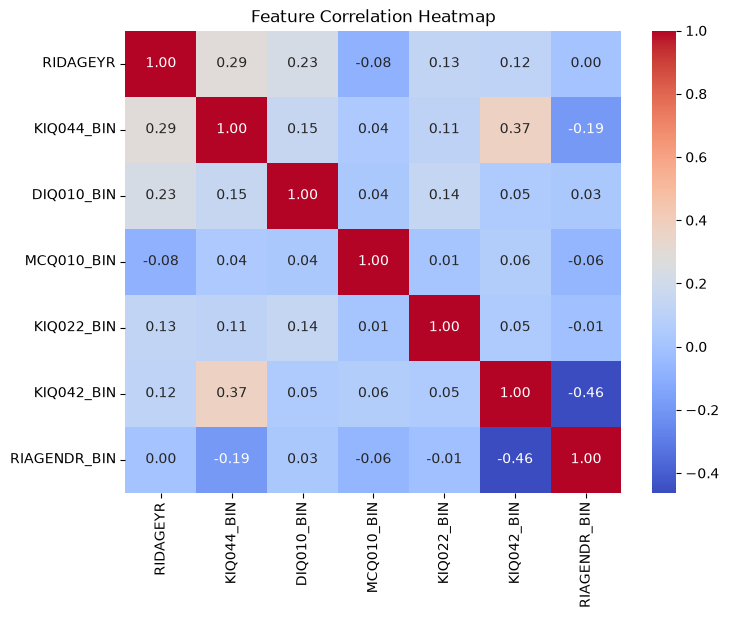

In [36]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    X_train.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()


In [37]:
!pip install scikeras


E0000 00:00:1787322716.506695 6088430 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


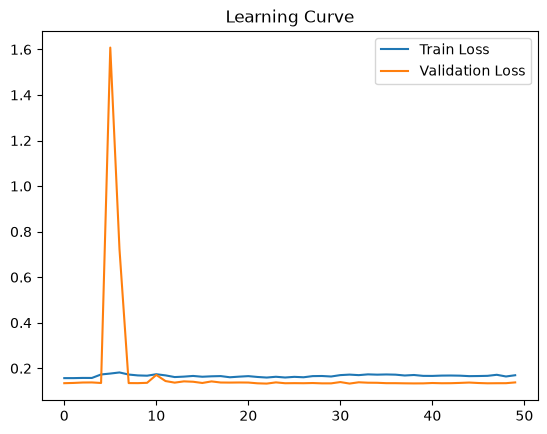

In [38]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.legend()
plt.title("Learning Curve")
plt.show()


In [39]:
#import sys
#!{sys.executable} -m pip install shap


In [40]:
#!pip install numpy==2.3.0


In [41]:
#!pip install ipywidgets


In [42]:
#!pip install jupyterlab_widgets



Running SHAP (logit-based) for Deep MLP


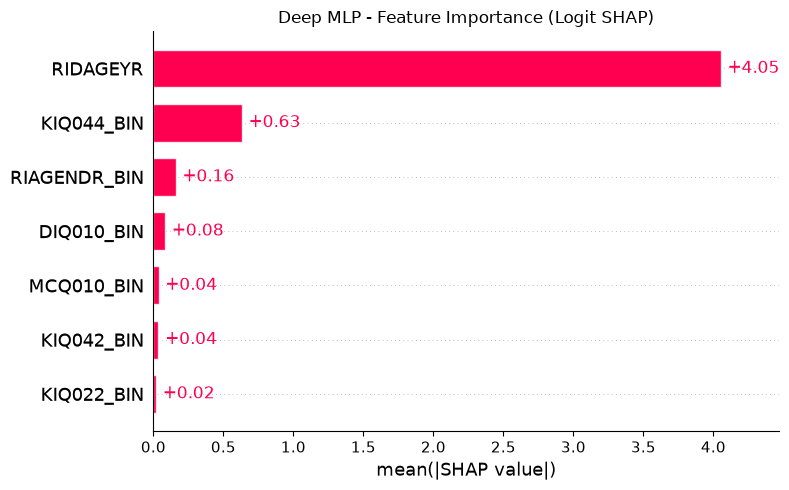


Running SHAP (logit-based) for Residual NN


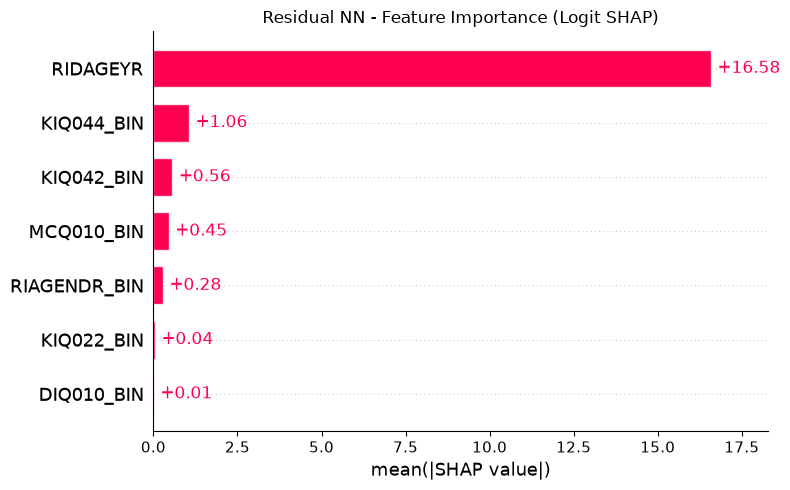


Running SHAP (logit-based) for Wide & Deep


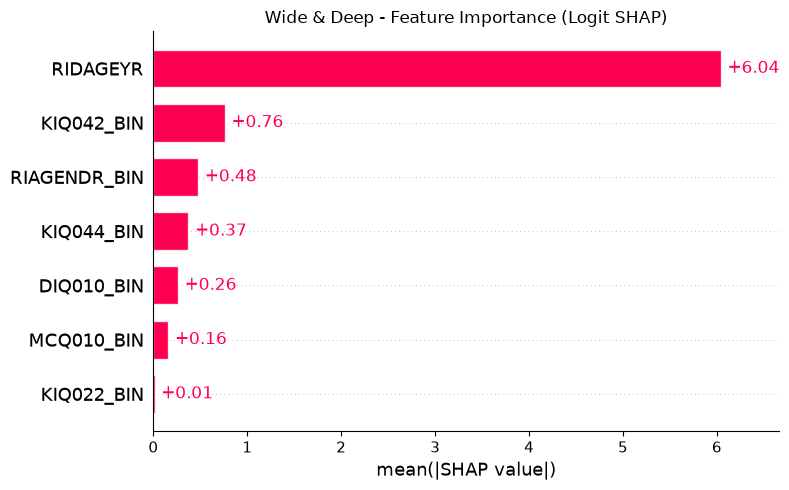

.values =
array([[-1.03473663e+01, -2.93472762e-01, -1.28225136e-01, ...,
         6.13068581e-03, -5.38900144e-01,  4.24856036e-01],
       [ 2.74081960e+00, -2.93472930e-01, -1.28225136e-01, ...,
         6.13067627e-03,  1.31937622e+00,  4.24856033e-01],
       [ 8.13007327e+00, -2.93472970e-01,  1.15402626e+00, ...,
         6.13067627e-03, -5.38900182e-01, -5.40725858e-01],
       ...,
       [-9.19252681e+00, -2.93472764e-01, -1.28225140e-01, ...,
         6.13068581e-03,  1.31937623e+00,  4.24856036e-01],
       [ 9.66986141e+00, -2.93472688e-01, -1.28225073e-01, ...,
         6.13068485e-03,  1.31937678e+00,  4.24856059e-01],
       [-3.41832752e+00,  5.21729634e-01, -1.28225136e-01, ...,
         6.13067611e-03,  1.31937622e+00, -5.40725857e-01]],
      shape=(300, 7))

.base_values =
array([21.19994197, 21.19994197, 21.19994197, 21.19994197, 21.19994197,
       21.19994197, 21.19994197, 21.19994197, 21.19994197, 21.19994197,
       21.19994197, 21.19994197, 21.19994197, 21.19

In [43]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model

# -------------------------------------------------
# Convert model → logit model
# -------------------------------------------------
def get_logit_model(trained_model):
    return Model(
        inputs=trained_model.input,
        outputs=trained_model.layers[-1].input  # pre-sigmoid
    )

# -------------------------------------------------
# SHAP function (modern API)
# -------------------------------------------------
def run_shap_analysis(model, X_train, X_test, feature_names, model_name):

    print(f"\nRunning SHAP (logit-based) for {model_name}")

    logit_model = get_logit_model(model)

    rng = np.random.default_rng(42)
    background = X_train[rng.choice(X_train.shape[0], 100, replace=False)]

    explainer = shap.Explainer(logit_model, background)

    shap_values = explainer(X_test[:300])

    # ---- If multi-output, select positive class (index 0 for logits)
    if len(shap_values.values.shape) == 3:
        shap_values = shap.Explanation(
            values=shap_values.values[:, :, 0],
            base_values=shap_values.base_values[:, 0],
            data=shap_values.data,
            feature_names=feature_names
        )

    # ---- Clean Bar Plot
    plt.figure()
    shap.plots.bar(shap_values, max_display=7, show=False)
    plt.title(f"{model_name} - Feature Importance (Logit SHAP)")
    plt.tight_layout()
    plt.show()
    return shap_values


# -------------------------------------------------
# Run for all models
# -------------------------------------------------
feature_names = list(X_train.columns)

run_shap_analysis(
    trained_models["Deep MLP"],
    X_train.values,
    X_test.values,
    feature_names,
    "Deep MLP"
)

run_shap_analysis(
    trained_models["Residual NN"],
    X_train.values,
    X_test.values,
    feature_names,
    "Residual NN"
)

run_shap_analysis(
    trained_models["Wide & Deep"],
    X_train.values,
    X_test.values,
    feature_names,
    "Wide & Deep"
)

In [44]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model


# -------------------------------------------------
# Convert trained model → logit model
# -------------------------------------------------
def get_logit_model(trained_model):
    return Model(
        inputs=trained_model.input,
        outputs=trained_model.layers[-1].input
    )


# -------------------------------------------------
# Waterfall Plot for Individual Record
# -------------------------------------------------
def run_shap_waterfall(model, X_train, X_test, feature_names, model_name, index=0):

    print(f"\nRunning Waterfall SHAP for {model_name} (Test index {index})")

    # Convert to logit model
    logit_model = get_logit_model(model)

    # Stable background
    rng = np.random.default_rng(42)
    background = X_train[rng.choice(X_train.shape[0], 100, replace=False)]

    # SHAP explainer
    explainer = shap.Explainer(logit_model, background)

    # Get SHAP values for single instance
    shap_values = explainer(X_test[index:index+1])

    # If multi-output detected → select class 0 (binary logit)
    if len(shap_values.values.shape) == 3:
        shap_values = shap.Explanation(
            values=shap_values.values[:, :, 0],
            base_values=shap_values.base_values[:, 0],
            data=shap_values.data,
            feature_names=feature_names
        )

    # Waterfall plot
    plt.figure()
    shap.plots.waterfall(shap_values[0], max_display=7, show=False)
    plt.title(f"{model_name} - SHAP Waterfall (Test Index {index})")
    plt.tight_layout()
    plt.show()


Running Waterfall SHAP for Deep MLP (Test index 76)


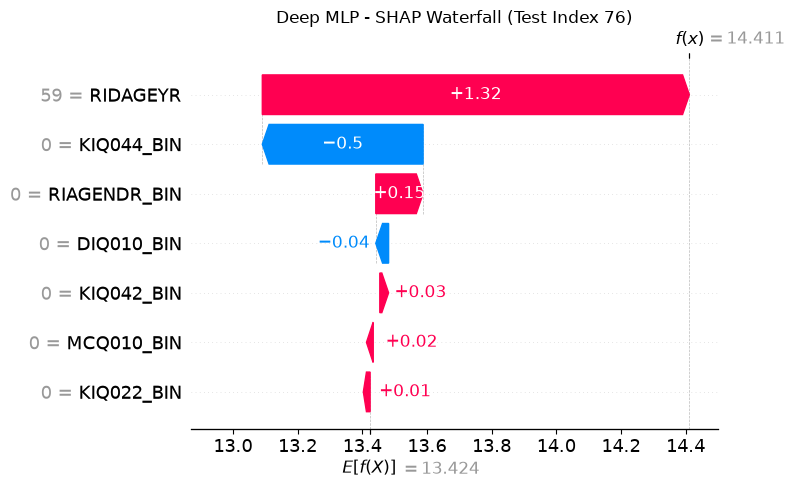

In [45]:
feature_names = list(X_train.columns)

run_shap_waterfall(
    trained_models["Deep MLP"],
    X_train.values,
    X_test.values,
    feature_names,
    "Deep MLP",
    index=76   # choose any patient index
)


Running Waterfall SHAP for Residual NN (Test index 76)


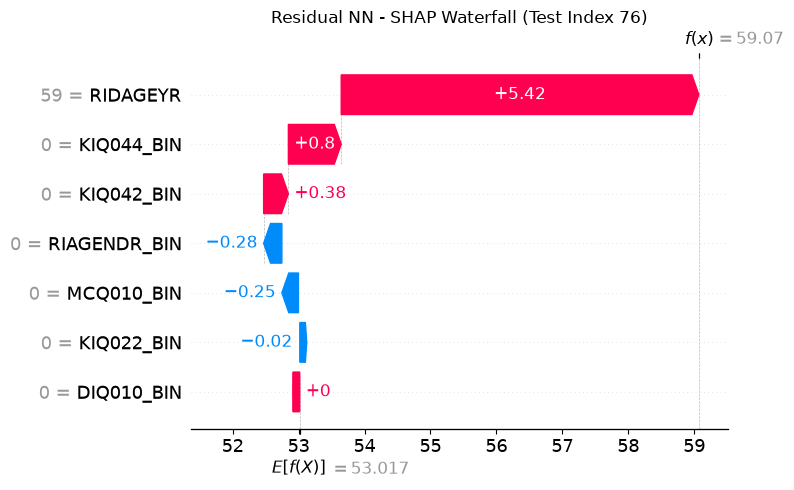

In [46]:
feature_names = list(X_train.columns)

run_shap_waterfall(
    trained_models["Residual NN"],
    X_train.values,
    X_test.values,
    feature_names,
    "Residual NN",
    index=76   # choose any patient index
)



Running Waterfall SHAP for Wide & Deep (Test index 76)


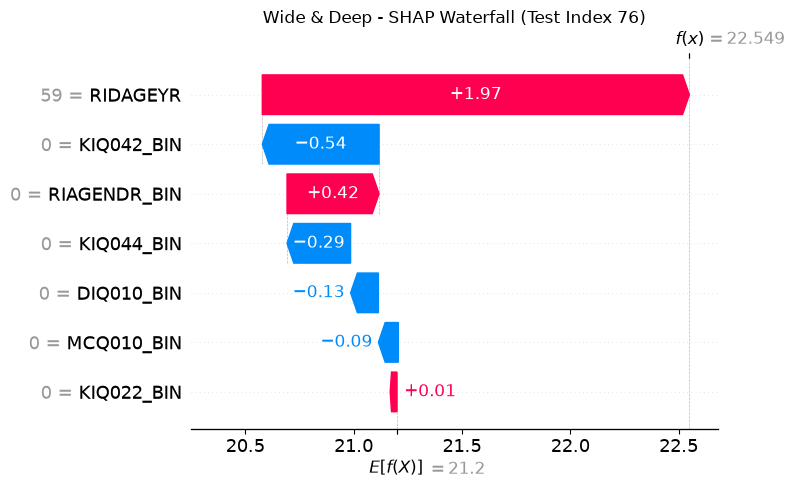

In [47]:
feature_names = list(X_train.columns)

run_shap_waterfall(
    trained_models["Wide & Deep"],
    X_train.values,
    X_test.values,
    feature_names,
    "Wide & Deep",
    index=76  # choose any patient index
)


In [48]:
def run_shap_beeswarm(model, X_train, X_test, feature_names, model_name):

    print(f"\nRunning SHAP (logit-based beeswarm) for {model_name}")

    logit_model = get_logit_model(model)

    rng = np.random.default_rng(42)
    background = X_train[rng.choice(X_train.shape[0], 100, replace=False)]

    explainer = shap.Explainer(logit_model, background)

    shap_values = explainer(X_test[:300])

    # Handle multi-output case
    if len(shap_values.values.shape) == 3:
        shap_values = shap.Explanation(
            values=shap_values.values[:, :, 0],
            base_values=shap_values.base_values[:, 0],
            data=shap_values.data,
            feature_names=feature_names
        )

    # ---- Beeswarm Plot (like your example)
    plt.figure()
    shap.plots.beeswarm(shap_values, max_display=10, show=False)
    plt.title(f"{model_name} - SHAP Impact on Model Output")
    plt.tight_layout()
    plt.show()

    return shap_values


Running SHAP (logit-based beeswarm) for Deep MLP


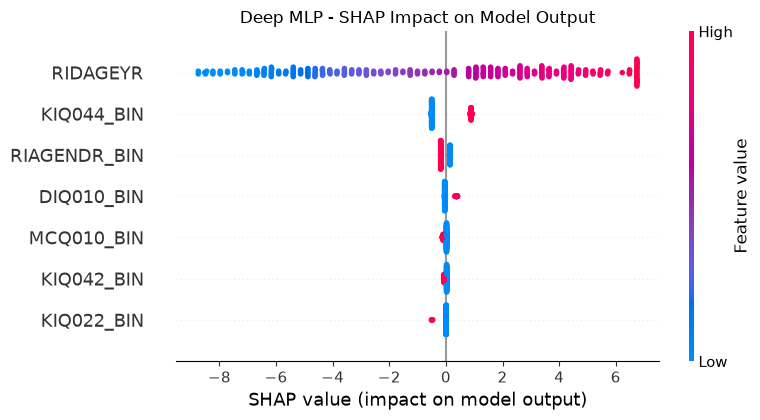

In [49]:
feature_names = list(X_train.columns)

shap_mlp = run_shap_beeswarm(
    trained_models["Deep MLP"],
    X_train.values,
    X_test.values,
    feature_names,
    "Deep MLP"
)


Running SHAP (logit-based beeswarm) for Residual NN


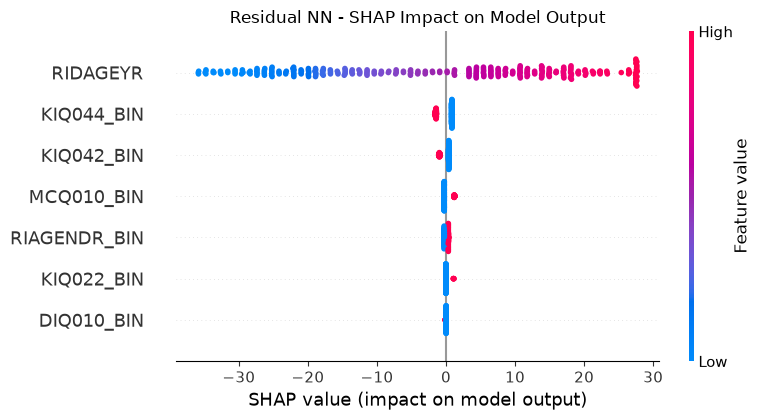

In [50]:
feature_names = list(X_train.columns)

shap_mlp = run_shap_beeswarm(
    trained_models["Residual NN"],
    X_train.values,
    X_test.values,
    feature_names,
    "Residual NN"
)


Running SHAP (logit-based beeswarm) for Wide & Deep


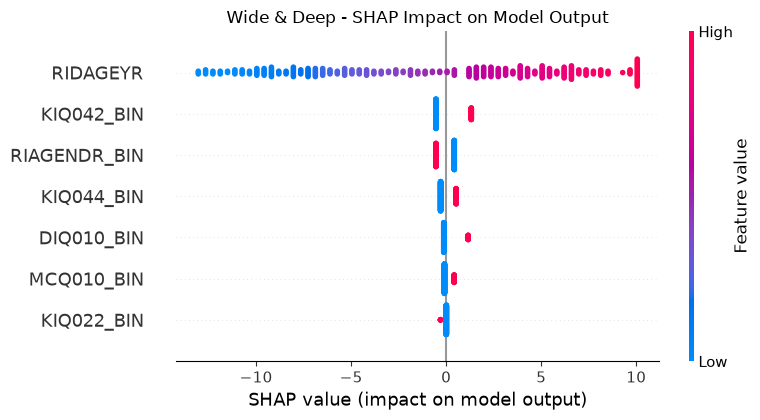

In [51]:
feature_names = list(X_train.columns)

shap_mlp = run_shap_beeswarm(
    trained_models["Wide & Deep"],
    X_train.values,
    X_test.values,
    feature_names,
    "Wide & Deep"
)